# Price Analysis

This notebook loads price data from the repo `data/` folder, combines the available days, and starts by calculating rolling volatility from the mid-price series.

Change `DATA_GLOB` if you want to narrow the input files.


In [12]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

DATA_GLOB = "../../data/prices_round_*.csv"
PRODUCT = "INTARIAN_PEPPER_ROOT"
ROLLING_WINDOW = 80



In [13]:
price_paths = sorted(Path().glob(DATA_GLOB))
raw_prices = pd.concat((pd.read_csv(path, sep=";") for path in price_paths), ignore_index=True)

prices = (
    raw_prices.loc[raw_prices["product"] == PRODUCT]
    .copy()
    .sort_values(["day", "timestamp"])
    .reset_index(drop=True)
)

# Recalculate mid_price as average of bid and ask when both available
prices["mid_price"] = prices.apply(
    lambda row: (row["bid_price_1"] + row["ask_price_1"]) / 2 
    if pd.notna(row["bid_price_1"]) and pd.notna(row["ask_price_1"]) 
    else np.nan, 
    axis=1
)

# Fill NaN mid_price with forward fill, then backward fill to avoid gaps in the series
prices["mid_price"] = prices["mid_price"].ffill().bfill()

prices["event_index"] = range(len(prices))
price_paths, prices[["day", "timestamp", "product", "bid_price_1", "ask_price_1", "mid_price"]].head()

([PosixPath('data/prices_round_1_day_-1.csv'),
  PosixPath('data/prices_round_1_day_-2.csv'),
  PosixPath('data/prices_round_1_day_0.csv')],
    day  timestamp               product  bid_price_1  ask_price_1  mid_price
 0   -2          0  INTARIAN_PEPPER_ROOT       9992.0      10005.0     9998.5
 1   -2        100  INTARIAN_PEPPER_ROOT       9995.0      10006.0    10000.5
 2   -2        200  INTARIAN_PEPPER_ROOT       9995.0      10008.0    10001.5
 3   -2        300  INTARIAN_PEPPER_ROOT          NaN      10006.0    10001.5
 4   -2        400  INTARIAN_PEPPER_ROOT       9992.0      10006.0     9999.0)

## Rolling Volatility

A common choice is to compute volatility on returns rather than on raw prices. Here we use percentage returns of the `mid_price`, then take a rolling standard deviation over the last `ROLLING_WINDOW` observations.


In [49]:
prices["mid_return"] = prices["mid_price"].pct_change()
prices[f"rolling_volatility_{ROLLING_WINDOW}"] = (
    prices["mid_return"].rolling(ROLLING_WINDOW).std() * (ROLLING_WINDOW ** 0.5)
)

prices[[
    "day",
    "timestamp",
    "mid_price",
    "mid_return",
    f"rolling_volatility_{ROLLING_WINDOW}",
]].tail(25)


,day,timestamp,mid_price,mid_return,rolling_volatility_80
29975,0,997500,12999.5,0.000192,0.000889
29976,0,997600,12996.0,-0.000269,0.000931
29977,0,997700,12996.0,0.000000,0.000930
29978,0,997800,12996.5,0.000038,0.000930
29979,0,997900,12999.5,0.000231,0.000851
29980,0,998000,12998.0,-0.000115,0.000754
29981,0,998100,12999.5,0.000115,0.000761
29982,0,998200,12999.5,0.000000,0.000761
29983,0,998300,12998.0,-0.000115,0.000771
29984,0,998400,12996.5,-0.000115,0.000781


In [50]:
prices[f"rolling_volatility_{ROLLING_WINDOW}"].describe()


count    29920.000000
mean         0.001288
std          0.000245
min          0.000632
25%          0.001121
50%          0.001283
75%          0.001445
max          0.002248
Name: rolling_volatility_80, dtype: float64

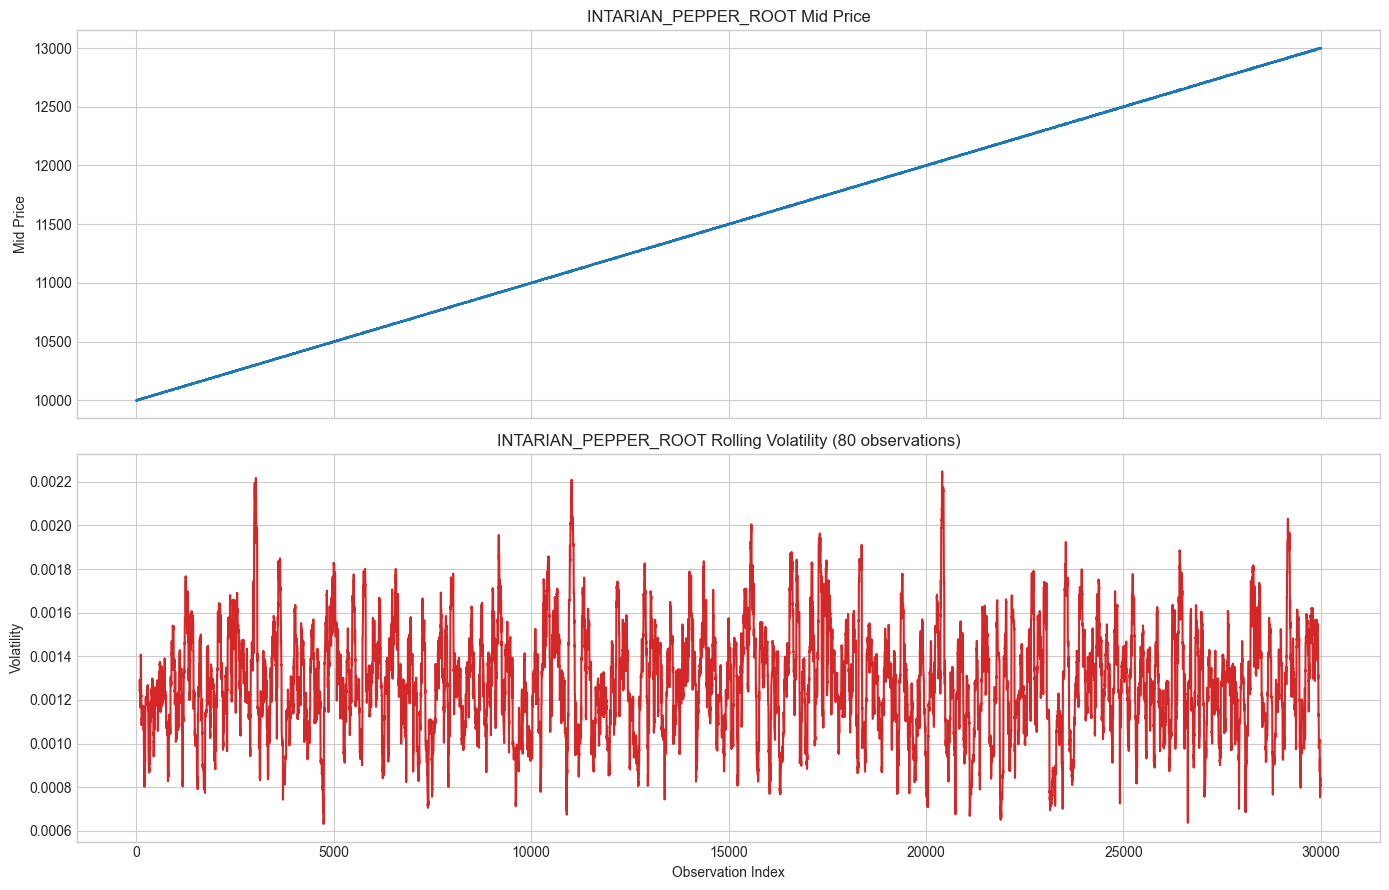

In [51]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(prices["event_index"], prices["mid_price"], color="tab:blue", linewidth=1.5)
axes[0].set_title(f"{PRODUCT} Mid Price")
axes[0].set_ylabel("Mid Price")

axes[1].plot(
    prices["event_index"],
    prices[f"rolling_volatility_{ROLLING_WINDOW}"],
    color="tab:red",
    linewidth=1.5,
)
axes[1].set_title(f"{PRODUCT} Rolling Volatility ({ROLLING_WINDOW} observations)")
axes[1].set_xlabel("Observation Index")
axes[1].set_ylabel("Volatility")

plt.tight_layout()
plt.show()


## Trend Persistence From Log Returns

To test whether the selected product trends tick to tick, compute log returns within each day, take the sign of each return, and compare it to the previous tick's sign. We also build a full transition matrix over the sign states `-1`, `0`, and `1` so the conditional transition probabilities and expected next-tick returns are all derived from the same underlying table.



In [5]:
prices["log_return"] = prices.groupby("day")["mid_price"].transform(lambda s: np.log(s).diff())
prices["log_return_sign"] = (
    pd.Series(np.sign(prices["log_return"]), index=prices.index)
    .replace({np.nan: pd.NA})
    .astype("Int64")
)
prices["prev_log_return_sign"] = prices.groupby("day")["log_return_sign"].shift(1).astype("Int64")
prices["prev_bid_price_1"] = prices.groupby("day")["bid_price_1"].shift(1)
prices["prev_ask_price_1"] = prices.groupby("day")["ask_price_1"].shift(1)

sign_states = [-1, 0, 1]
transition_frame = prices.loc[
    prices["prev_log_return_sign"].notna() & prices["log_return_sign"].notna(),
    [
        "day",
        "timestamp",
        "prev_log_return_sign",
        "log_return_sign",
        "log_return",
        "bid_price_1",
        "ask_price_1",
        "prev_bid_price_1",
        "prev_ask_price_1",
    ],
].copy()
transition_frame["prev_log_return_sign"] = transition_frame["prev_log_return_sign"].astype(int)
transition_frame["log_return_sign"] = transition_frame["log_return_sign"].astype(int)
trade_is_executable = (
    transition_frame["prev_ask_price_1"].notna()
    & transition_frame["bid_price_1"].notna()
    & transition_frame["prev_ask_price_1"].gt(0)
    & transition_frame["bid_price_1"].gt(0)
)
transition_frame["buy_ask_sell_bid_log_return"] = np.where(
    trade_is_executable,
    np.log(transition_frame["bid_price_1"] / transition_frame["prev_ask_price_1"]),
    np.nan,
)
transition_frame["buy_ask_sell_bid_simple_return_pct"] = np.where(
    trade_is_executable,
    (transition_frame["bid_price_1"] / transition_frame["prev_ask_price_1"] - 1.0) * 100,
    np.nan,
)
transition_frame["buy_ask_sell_bid_pnl_ticks"] = np.where(
    trade_is_executable,
    transition_frame["bid_price_1"] - transition_frame["prev_ask_price_1"],
    np.nan,
)

transition_counts = pd.crosstab(
    transition_frame["prev_log_return_sign"],
    transition_frame["log_return_sign"],
).reindex(index=sign_states, columns=sign_states, fill_value=0)

transition_probs = (
    transition_counts.div(transition_counts.sum(axis=1).replace(0, np.nan), axis=0)
    .fillna(0.0)
    * 100.0
).round(2)
transition_pct_of_all = (
    transition_counts / len(transition_frame) * 100.0
    if len(transition_frame) > 0
    else transition_counts.astype(float)
).round(2)

expected_returns = (
    transition_frame.groupby(["prev_log_return_sign", "log_return_sign"])["log_return"]
    .mean()
    .unstack()
    .reindex(index=sign_states, columns=sign_states)
)
buy_ask_sell_bid_counts = (
    transition_frame.groupby(["prev_log_return_sign", "log_return_sign"])["buy_ask_sell_bid_log_return"]
    .count()
    .unstack()
    .reindex(index=sign_states, columns=sign_states, fill_value=0)
)
buy_ask_sell_bid_returns = (
    transition_frame.groupby(["prev_log_return_sign", "log_return_sign"])["buy_ask_sell_bid_log_return"]
    .mean()
    .unstack()
    .reindex(index=sign_states, columns=sign_states)
)
buy_ask_sell_bid_simple_returns = (
    transition_frame.groupby(["prev_log_return_sign", "log_return_sign"])["buy_ask_sell_bid_simple_return_pct"]
    .mean()
    .unstack()
    .reindex(index=sign_states, columns=sign_states)
)
buy_ask_sell_bid_pnl_ticks = (
    transition_frame.groupby(["prev_log_return_sign", "log_return_sign"])["buy_ask_sell_bid_pnl_ticks"]
    .mean()
    .unstack()
    .reindex(index=sign_states, columns=sign_states)
)

transition_summary = pd.DataFrame(
    [
        {
            "prev_sign": prev,
            "next_sign": next_,
            "transition": f"{prev} -> {next_}",
            "count": int(transition_counts.loc[prev, next_]),
            "pct_of_all_transitions": float(transition_pct_of_all.loc[prev, next_]),
            "pct_given_previous_sign": float(transition_probs.loc[prev, next_]),
            "expected_log_return": expected_returns.loc[prev, next_],
            "buy_ask_sell_bid_count": int(buy_ask_sell_bid_counts.loc[prev, next_]),
            "buy_ask_sell_bid_ev_log_return": buy_ask_sell_bid_returns.loc[prev, next_],
            "buy_ask_sell_bid_ev_simple_return_pct": buy_ask_sell_bid_simple_returns.loc[prev, next_],
            "buy_ask_sell_bid_ev_pnl_ticks": buy_ask_sell_bid_pnl_ticks.loc[prev, next_],
        }
        for prev in sign_states
        for next_ in sign_states
    ]
)
transition_summary["expected_simple_return_pct"] = np.where(
    transition_summary["expected_log_return"].notna(),
    (np.exp(transition_summary["expected_log_return"]) - 1) * 100,
    np.nan,
)
transition_summary["spread_crossing_drag_pct"] = (
    transition_summary["expected_simple_return_pct"]
    - transition_summary["buy_ask_sell_bid_ev_simple_return_pct"]
)

nonzero_transitions = transition_frame.loc[
    transition_frame["prev_log_return_sign"].ne(0) & transition_frame["log_return_sign"].ne(0)
].copy()

same_sign_share = (
    (nonzero_transitions["log_return_sign"] == nonzero_transitions["prev_log_return_sign"]).mean()
    if not nonzero_transitions.empty
    else np.nan
)
opposite_sign_share = 1 - same_sign_share if pd.notna(same_sign_share) else np.nan
zero_involved_share = (
    ((transition_frame["log_return_sign"] == 0) | (transition_frame["prev_log_return_sign"] == 0)).mean()
    if not transition_frame.empty
    else np.nan
)

trend_summary = pd.DataFrame(
    {
        "same_sign_pct": [same_sign_share * 100 if pd.notna(same_sign_share) else np.nan],
        "opposite_sign_pct": [opposite_sign_share * 100 if pd.notna(opposite_sign_share) else np.nan],
        "zero_involved_pct": [zero_involved_share * 100 if pd.notna(zero_involved_share) else np.nan],
        "observations_used": [int(len(nonzero_transitions))],
        "all_transitions": [int(len(transition_frame))],
    },
    index=["overall"],
).round(2)

trend_by_day = (
    nonzero_transitions
    .assign(same_sign=lambda df: df["log_return_sign"] == df["prev_log_return_sign"])
    .groupby("day")["same_sign"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "same_sign_pct", "count": "observations_used"})
)
if not trend_by_day.empty:
    trend_by_day["opposite_sign_pct"] = ((1 - trend_by_day["same_sign_pct"]) * 100).round(2)
    trend_by_day["same_sign_pct"] = (trend_by_day["same_sign_pct"] * 100).round(2)

print(
    f"{PRODUCT} shows short-horizon trend persistence."
    if pd.notna(trend_summary.loc["overall", "same_sign_pct"]) and trend_summary.loc["overall", "same_sign_pct"] > 50
    else f"{PRODUCT} does not show short-horizon trend persistence; sign flips are more common than same-direction moves."
)

trend_summary, trend_by_day, transition_counts, transition_probs, transition_pct_of_all, expected_returns, buy_ask_sell_bid_returns, transition_summary



ASH_COATED_OSMIUM does not show short-horizon trend persistence; sign flips are more common than same-direction moves.


(         same_sign_pct  opposite_sign_pct  zero_involved_pct  observations_used  all_transitions
 overall          23.93              76.07              57.28              12812            29994,
      same_sign_pct  observations_used  opposite_sign_pct
 day                                                     
 -2           23.04               4244              76.96
 -1           24.66               4274              75.34
  0           24.08               4294              75.92,
 log_return_sign         -1     0     1
 prev_log_return_sign                  
 -1                    1527  2910  4889
  0                    2942  5406  2946
  1                    4857  2978  1539,
 log_return_sign          -1      0      1
 prev_log_return_sign                     
 -1                    16.37  31.20  52.42
  0                    26.05  47.87  26.08
  1                    51.81  31.77  16.42,
 log_return_sign          -1      0      1
 prev_log_return_sign                     
 -1      

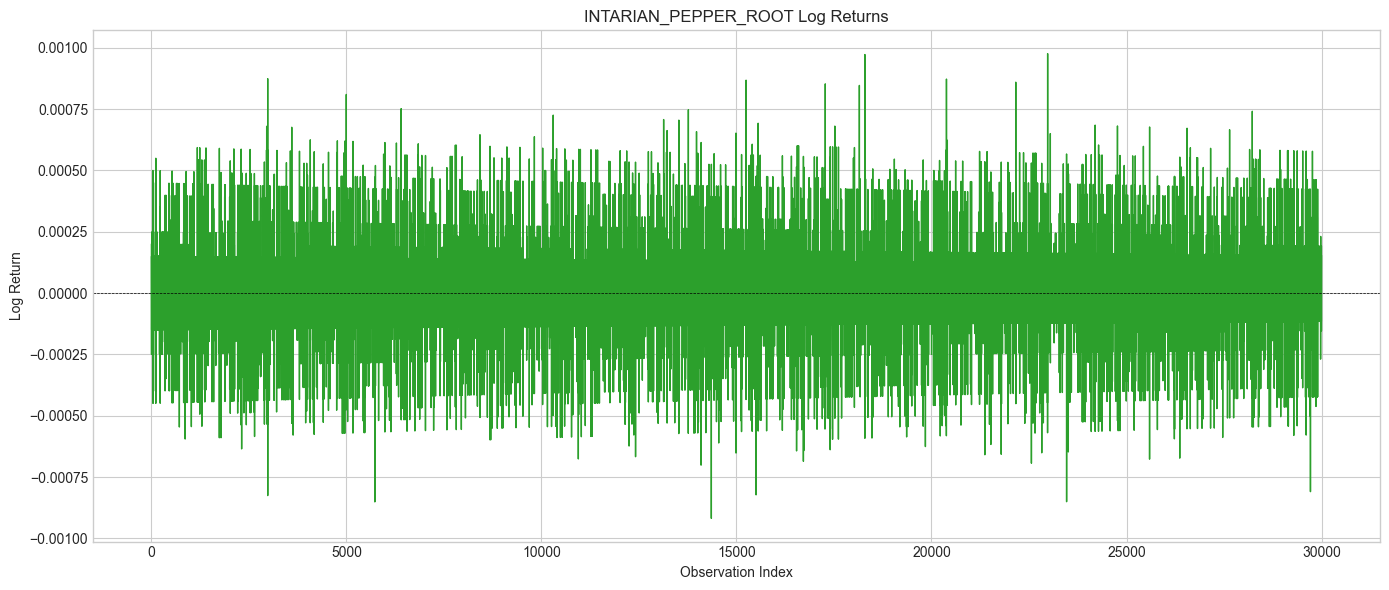

In [53]:
trend_summary, trend_by_day
# Plot log returns
plt.figure(figsize=(14, 6))
plt.plot(prices["event_index"], prices["log_return"], color="tab:green", linewidth=1)
plt.title(f"{PRODUCT} Log Returns")
plt.xlabel("Observation Index")
plt.ylabel("Log Return")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

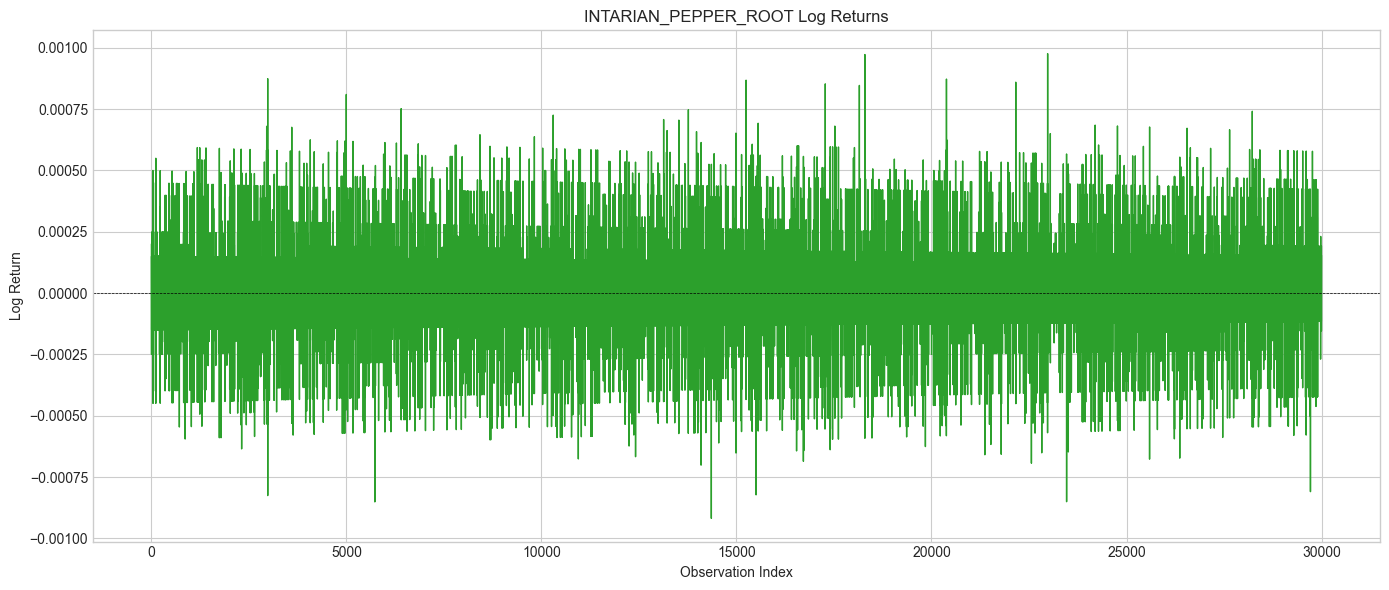

In [54]:
# Plot log returns
plt.figure(figsize=(14, 6))
plt.plot(prices["event_index"], prices["log_return"], color="tab:green", linewidth=1)
plt.title(f"{PRODUCT} Log Returns")
plt.xlabel("Observation Index")
plt.ylabel("Log Return")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


In [ ]:
## Historical Average Slope Analysis

Compute the overall linear slope of mid_price over time, then divide the data into 4 equal chunks and compute the average slope for each chunk.

In [14]:
from sklearn.linear_model import LinearRegression

# Overall slope
X = prices[['event_index']].values
y = prices['mid_price'].values
overall_model = LinearRegression()
overall_model.fit(X, y)
overall_slope = overall_model.coef_[0]
print(f"Overall average slope: {overall_slope:.6f}")

# Divide into 4 chunks
n = len(prices)
chunk_size = n // 4
chunk_slopes = []
for i in range(4):
    start = i * chunk_size
    end = (i + 1) * chunk_size if i < 3 else n
    chunk_X = prices.iloc[start:end][['event_index']].values
    chunk_y = prices.iloc[start:end]['mid_price'].values
    if len(chunk_X) > 1:
        model = LinearRegression()
        model.fit(chunk_X, chunk_y)
        slope = model.coef_[0]
        chunk_slopes.append(slope)
        print(f"Chunk {i+1} (indices {start} to {end-1}): slope = {slope:.6f}")
    else:
        chunk_slopes.append(0)
        print(f"Chunk {i+1}: not enough data")

print(f"\nChunk slopes: {chunk_slopes}")

Overall average slope: 0.100000
Chunk 1 (indices 0 to 7499): slope = 0.099995
Chunk 2 (indices 7500 to 14999): slope = 0.099994
Chunk 3 (indices 15000 to 22499): slope = 0.099999
Chunk 4 (indices 22500 to 29999): slope = 0.099997

Chunk slopes: [np.float64(0.09999548562480864), np.float64(0.09999445784879042), np.float64(0.09999857001241906), np.float64(0.09999703004439169)]


In [15]:
# Create a continuous time axis
prices['cumulative_timestamp'] = prices.groupby('day')['timestamp'].transform(lambda x: x - x.min()) + (prices['day'] - prices['day'].min()) * 24 * 60 * 60 * 1000  # assuming days are separate

# Overall slope using time
X_time = prices[['cumulative_timestamp']].values
y = prices['mid_price'].values
overall_model_time = LinearRegression()
overall_model_time.fit(X_time, y)
overall_slope_time = overall_model_time.coef_[0]
print(f"Overall average slope (per ms): {overall_slope_time:.10f}")

# Divide into 4 chunks by time
total_time = prices['cumulative_timestamp'].max()
chunk_time_size = total_time / 4
chunk_slopes_time = []
for i in range(4):
    start_time = i * chunk_time_size
    end_time = (i + 1) * chunk_time_size if i < 3 else total_time + 1
    chunk_mask = (prices['cumulative_timestamp'] >= start_time) & (prices['cumulative_timestamp'] < end_time)
    chunk_X = prices.loc[chunk_mask, ['cumulative_timestamp']].values
    chunk_y = prices.loc[chunk_mask, 'mid_price'].values
    if len(chunk_X) > 1:
        model = LinearRegression()
        model.fit(chunk_X, chunk_y)
        slope = model.coef_[0]
        chunk_slopes_time.append(slope)
        print(f"Chunk {i+1} (time {start_time:.0f} to {end_time-1:.0f}): slope = {slope:.10f}")
    else:
        chunk_slopes_time.append(0)
        print(f"Chunk {i+1}: not enough data")

print(f"\nChunk slopes (per ms): {chunk_slopes_time}")

Overall average slope (per ms): 0.0000115907
Chunk 1 (time 0 to 43449974): slope = 0.0010000037
Chunk 2 (time 43449975 to 86899949): slope = 0.0010000552
Chunk 3 (time 86899950 to 130349924): slope = 0.0009999802
Chunk 4 (time 130349925 to 173799900): slope = 0.0009999797

Chunk slopes (per ms): [np.float64(0.0010000036945300372), np.float64(0.0010000552360022092), np.float64(0.0009999802055192081), np.float64(0.0009999797120497972)]


In [16]:
# Slope on log price (continuous compounding growth rate)
prices['log_mid_price'] = np.log(prices['mid_price'])

X = prices[['event_index']].values
y_log = prices['log_mid_price'].values
log_model = LinearRegression()
log_model.fit(X, y_log)
log_slope = log_model.coef_[0]
print(f"Overall log price slope (per observation): {log_slope:.8f}")
print(f"Equivalent annual growth rate (assuming 100ms intervals): {(np.exp(log_slope * 10 * 365 * 24 * 60 * 60) - 1) * 100:.4f}%")

# Chunk log slopes
chunk_log_slopes = []
for i in range(4):
    start = i * chunk_size
    end = (i + 1) * chunk_size if i < 3 else n
    chunk_X = prices.iloc[start:end][['event_index']].values
    chunk_y_log = prices.iloc[start:end]['log_mid_price'].values
    if len(chunk_X) > 1:
        model = LinearRegression()
        model.fit(chunk_X, chunk_y_log)
        slope = model.coef_[0]
        chunk_log_slopes.append(slope)
        print(f"Chunk {i+1} log slope: {slope:.8f}")
    else:
        chunk_log_slopes.append(0)

print(f"\nChunk log slopes: {chunk_log_slopes}")
print(f"Average chunk log slope: {np.mean(chunk_log_slopes):.8f}")

Overall log price slope (per observation): 0.00000873
Equivalent annual growth rate (assuming 100ms intervals): inf%
Chunk 1 log slope: 0.00000964
Chunk 2 log slope: 0.00000899
Chunk 3 log slope: 0.00000842
Chunk 4 log slope: 0.00000792

Chunk log slopes: [np.float64(9.640724872026977e-06), np.float64(8.990379198535208e-06), np.float64(8.422651851695981e-06), np.float64(7.922010803797637e-06)]
Average chunk log slope: 0.00000874


/tmp/ipykernel_15024/2421798012.py:10: RuntimeWarning: overflow encountered in exp
  print(f"Equivalent annual growth rate (assuming 100ms intervals): {(np.exp(log_slope * 10 * 365 * 24 * 60 * 60) - 1) * 100:.4f}%")


In [8]:
# Check timestamp differences
prices['timestamp_diff'] = prices.groupby('day')['timestamp'].diff().fillna(0)
print("Timestamp differences summary:")
print(prices['timestamp_diff'].describe())
print(f"Most common diff: {prices['timestamp_diff'].mode().iloc[0]} ms")

Timestamp differences summary:
count    30000.000000
mean        99.990000
std          0.999967
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: timestamp_diff, dtype: float64
Most common diff: 100.0 ms


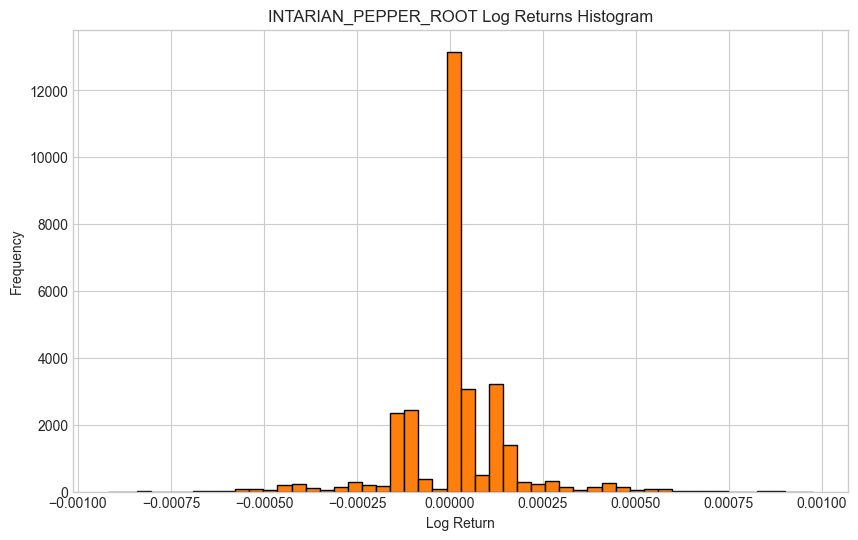

Log Returns Stats:
Positive: 9955 (33.19%)
Negative: 6888 (22.96%)
Zero: 13154 (43.85%)
Total observations: 29997


In [55]:
# Histogram of log returns
plt.figure(figsize=(10, 6))
plt.hist(prices["log_return"].dropna(), bins=50, color="tab:orange", edgecolor="black")
plt.title(f"{PRODUCT} Log Returns Histogram")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()


# Stats on log returns signs
log_returns_clean = prices["log_return"].dropna()
positive = (log_returns_clean > 0).sum()
negative = (log_returns_clean < 0).sum()
zero = (log_returns_clean == 0).sum()
total = len(log_returns_clean)

print(f"Log Returns Stats:")
print(f"Positive: {positive} ({positive/total*100:.2f}%)")
print(f"Negative: {negative} ({negative/total*100:.2f}%)")
print(f"Zero: {zero} ({zero/total*100:.2f}%)")
print(f"Total observations: {total}")

In [56]:
# Full transition summary across all 9 sign-to-sign transitions
transition_summary_display = transition_summary.copy()
transition_summary_display["expected_log_return"] = transition_summary_display["expected_log_return"].round(6)
transition_summary_display["expected_simple_return_pct"] = transition_summary_display["expected_simple_return_pct"].round(4)
transition_summary_display["buy_ask_sell_bid_ev_log_return"] = transition_summary_display["buy_ask_sell_bid_ev_log_return"].round(6)
transition_summary_display["buy_ask_sell_bid_ev_simple_return_pct"] = transition_summary_display["buy_ask_sell_bid_ev_simple_return_pct"].round(4)
transition_summary_display["buy_ask_sell_bid_ev_pnl_ticks"] = transition_summary_display["buy_ask_sell_bid_ev_pnl_ticks"].round(4)
transition_summary_display["spread_crossing_drag_pct"] = transition_summary_display["spread_crossing_drag_pct"].round(4)

print("\nFull transition summary:")
display(
    transition_summary_display[[
        "transition",
        "count",
        "pct_of_all_transitions",
        "pct_given_previous_sign",
        "expected_log_return",
        "expected_simple_return_pct",
        "buy_ask_sell_bid_count",
        "buy_ask_sell_bid_ev_log_return",
        "buy_ask_sell_bid_ev_simple_return_pct",
        "buy_ask_sell_bid_ev_pnl_ticks",
        "spread_crossing_drag_pct",
    ]]
)




Full transition summary:


,transition,count,pct_of_all_transitions,pct_given_previous_sign,expected_log_return,expected_simple_return_pct,buy_ask_sell_bid_count,buy_ask_sell_bid_ev_log_return,buy_ask_sell_bid_ev_simple_return_pct,buy_ask_sell_bid_ev_pnl_ticks,spread_crossing_drag_pct
0,-1 -> -1,615,2.05,8.93,-0.000171,-0.0171,615,-0.001294,-0.1293,-14.8878,0.1122
1,-1 -> 0,2317,7.72,33.64,0.000000,0.0000,2039,-0.001122,-0.1122,-12.9147,0.1122
2,-1 -> 1,3955,13.19,57.43,0.000185,0.0185,3955,-0.000957,-0.0956,-10.9942,0.1141
3,0 -> -1,2333,7.78,17.74,-0.000156,-0.0156,2091,-0.001303,-0.1302,-14.9627,0.1146
4,0 -> 0,6769,22.57,51.46,0.000000,0.0000,5867,-0.001108,-0.1107,-12.7380,0.1107
5,0 -> 1,4052,13.51,30.80,0.000118,0.0118,3551,-0.001037,-0.1036,-11.9209,0.1154
6,1 -> -1,3940,13.14,39.59,-0.000178,-0.0178,3940,-0.001329,-0.1328,-15.2878,0.1150
7,1 -> 0,4068,13.56,40.87,0.000000,0.0000,3667,-0.001132,-0.1132,-13.0213,0.1132
8,1 -> 1,1945,6.48,19.54,0.000115,0.0115,1945,-0.001021,-0.1020,-11.7496,0.1136


In [44]:
# Matrix views for probabilities and expected returns
print("\nConditional transition probabilities (%):")
display(transition_probs)

print("\nExpected log return by transition:")
display(expected_returns.round(6))

print("\nExpected buy-at-ask / sell-at-bid log return by transition:")
display(buy_ask_sell_bid_returns.round(6))

print("\nExpected buy-at-ask / sell-at-bid simple return (%) by transition:")
display(buy_ask_sell_bid_simple_returns.round(4))

# Expected value from buying at first tick and holding entire series
total_log_return = prices["log_return"].sum()
total_return_pct = (np.exp(total_log_return) - 1) * 100
avg_log_return_per_tick = prices["log_return"].mean()
num_ticks = len(prices["log_return"].dropna())

print("Buy and Hold Strategy:")
print(f"Total log return: {total_log_return:.6f}")
print(f"Total return: {total_return_pct:.2f}%")
print(f"Average log return per tick: {avg_log_return_per_tick:.6f}")
print(f"Number of ticks: {num_ticks}")
print(f"Expected value per tick (average log return): {avg_log_return_per_tick:.6f}")




Conditional transition probabilities (%):


log_return_sign,-1,0,1
prev_log_return_sign,,,
-1,8.93,33.64,57.43
0,17.74,51.46,30.80
1,39.59,40.87,19.54



Expected log return by transition:


log_return_sign,-1,0,1
prev_log_return_sign,,,
-1,-0.000171,0.0,0.000185
0,-0.000156,0.0,0.000118
1,-0.000178,0.0,0.000115


Buy and Hold Strategy:
Total log return: 0.262745
Total return: 30.05%
Average log return per tick: 0.000009
Number of ticks: 29997
Expected value per tick (average log return): 0.000009


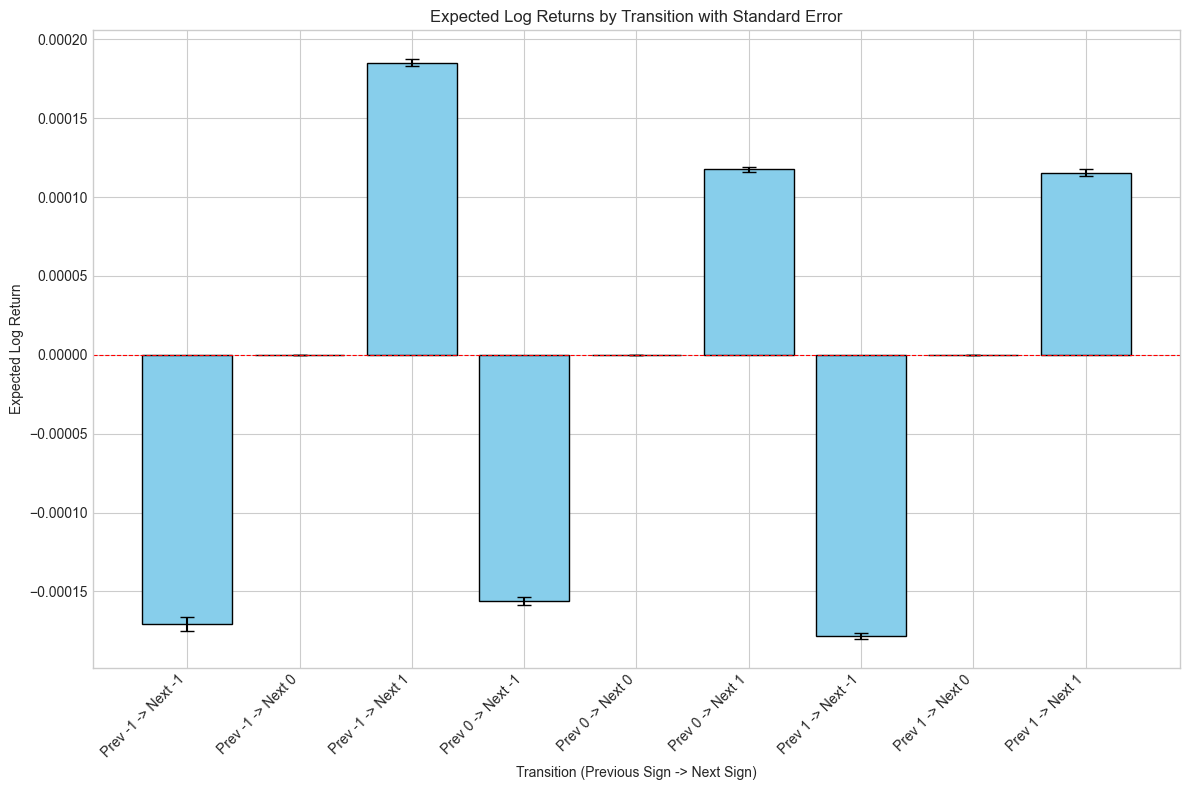

In [45]:
# Compute standard errors for each transition (std / sqrt(n))
se_returns = pd.DataFrame(0.0, index=transition_counts.index, columns=transition_counts.columns)
for prev in transition_counts.index:
    for next_ in transition_counts.columns:
        transition_slice = transition_frame.loc[
            (transition_frame["prev_log_return_sign"] == prev)
            & (transition_frame["log_return_sign"] == next_),
            "log_return",
        ]
        count = len(transition_slice)
        if count > 1:
            se_returns.loc[prev, next_] = transition_slice.std(ddof=1) / np.sqrt(count)

# Bar plot of expected returns with standard error bars
fig, ax = plt.subplots(figsize=(12, 8))
transitions = []
means = []
ses = []
for prev in transition_counts.index:
    for next_ in transition_counts.columns:
        transitions.append(f"Prev {prev} -> Next {next_}")
        means.append(0.0 if pd.isna(expected_returns.loc[prev, next_]) else expected_returns.loc[prev, next_])
        ses.append(se_returns.loc[prev, next_])

bars = ax.bar(transitions, means, yerr=ses, capsize=5, color='skyblue', edgecolor='black')
ax.set_title("Expected Log Returns by Transition with Standard Error")
ax.set_xlabel("Transition (Previous Sign -> Next Sign)")
ax.set_ylabel("Expected Log Return")
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [ ]:
print(f"Expected value per tick (average log return): {avg_log_return_per_tick:.6f}")

# Augmented Dickey-Fuller Test for Stationarity
from statsmodels.tsa.stattools import adfuller

# Test on log returns
result_returns = adfuller(prices["log_return"].dropna())
print("ADF Test on Log Returns:")
print(f"ADF Statistic: {result_returns[0]:.4f}")
print(f"p-value: {result_returns[1]:.4f}")
print("Critical Values:")
for key, value in result_returns[4].items():
    print(f"  {key}: {value:.4f}")
if result_returns[1] < 0.05:
    print("Conclusion: Log returns are stationary (reject null hypothesis of unit root).")
else:
    print("Conclusion: Log returns are non-stationary (fail to reject null hypothesis).")

# Test on prices (for comparison)
result_prices = adfuller(prices["mid_price"].dropna())
print("\nADF Test on Mid Prices:")
print(f"ADF Statistic: {result_prices[0]:.4f}")
print(f"p-value: {result_prices[1]:.4f}")
if result_prices[1] < 0.05:
    print("Conclusion: Prices are stationary.")
else:
    print("Conclusion: Prices are non-stationary (likely has a unit root).")


## Interpretation of Stationarity Tests

The ADF test results show that log returns are stationary (p-value ≈ 0.000), while mid prices are non-stationary. This combination is evidence of mean-reverting behavior with a long-term trend:

- **Stationary log returns**: The price changes are mean-reverting - deviations from the trend tend to correct themselves over time.
- **Non-stationary prices**: The price series has a unit root, indicating persistence and a long-term upward trend.
- **Implication**: The series exhibits mean reversion around a trending path, common in many financial assets where prices drift upward but fluctuate around that trend.

In [ ]:
# Strategy: Always buy after a negative log return (hold for one tick)
trade_mask = (
    prices["prev_log_return_sign"].eq(-1) & 
    prices["log_return"].notna()
)

expected_log_return_per_trade = prices.loc[trade_mask, "log_return"].mean()
num_trades = trade_mask.sum()
winning_trades = (prices.loc[trade_mask, "log_return"] > 0).sum()
win_rate = winning_trades / num_trades * 100 if num_trades > 0 else 0

expected_total_log_return = num_trades * expected_log_return_per_trade
expected_total_return_pct = (np.exp(expected_total_log_return) - 1) * 100

print("Strategy: Always Buy After Negative Log Return")
print(f"Number of trades: {num_trades}")
print(f"Winning trades: {winning_trades}")
print(f"Win rate: {win_rate:.2f}%")
print(f"Expected log return per trade: {expected_log_return_per_trade:.6f}")
print(f"Expected total log return: {expected_total_log_return:.6f}")
print(f"Expected total return: {expected_total_return_pct:.2f}%")

# Compare to buy-and-hold
print("\nComparison to Buy-and-Hold:")
print(f"Buy-and-Hold total return: {total_return_pct:.2f}%")
print(f"Strategy vs Buy-and-Hold: {expected_total_return_pct - total_return_pct:.2f} percentage points difference")

In [ ]:
# Calculate Kelly Criterion for mean reversion strategy
positive_returns = prices.loc[trade_mask & (prices["log_return"] > 0), "log_return"]
negative_returns = prices.loc[trade_mask & (prices["log_return"] < 0), "log_return"]

avg_win = positive_returns.mean()
avg_loss = negative_returns.mean()  # negative value
win_prob = len(positive_returns) / num_trades
loss_prob = len(negative_returns) / num_trades

# Kelly fraction: f = (b*p - q)/b where b = avg_win / |avg_loss|
b = avg_win / abs(avg_loss)
kelly_fraction = (b * win_prob - loss_prob) / b

print("Kelly Criterion Calculation:")
print(f"Average win: {avg_win:.6f}")
print(f"Average loss: {abs(avg_loss):.6f}")
print(f"Win probability: {win_prob:.4f}")
print(f"Loss probability: {loss_prob:.4f}")
print(f"Odds ratio (b): {b:.4f}")
print(f"Kelly fraction: {kelly_fraction:.4f} ({kelly_fraction*100:.2f}% of capital per trade)")

## Capital Allocation and Trading Rules (Unlimited Capital, Limited Position Size)

With unlimited capital but limited position sizes (e.g., max 100 units per product in IMC Prosperity), allocation shifts from capital percentages to position utilization and strategy prioritization. The focus becomes maximizing position efficiency and managing inventory within limits.

### Mean Reversion Strategy
- **Signal**: Buy after a negative log return (prev_log_return_sign == -1)
- **Holding Period**: 1 tick
- **Win Rate**: 57.43%, Expected Return per Trade: 0.000091
- **Position Sizing**: 
  - Max position size (e.g., 100 units) = 100% utilization
  - Kelly suggests 49.19% of max position per trade → Use 25-50 units per trade
  - Since capital unlimited, you can run this on multiple uncorrelated assets simultaneously
- **Risk Management**: Stop loss at 2x average loss, max 5% position utilization drawdown
- **Allocation**: 40-50% of available position slots (prioritize high-edge assets)

### Market Making Strategy
- **Quoting Rules**: 
  - Bid = mid_price - spread/2, Ask = mid_price + spread/2
  - Spread = 0.5 × rolling_volatility_80 (or competitive level)
  - Quote at max position size (100 units per side) since capital unlimited
- **Inventory Management**: 
  - Target: 0 inventory
  - Adjust quotes aggressively to reduce position
  - If inventory > 20 units: Widen spread by 2x
  - If inventory < -20 units: Tighten spread by 0.5x
  - Max inventory: 50 units (50% of limit)
- **Allocation**: 50-60% of position slots (can run on all available products)
- **Risk**: Monitor inventory risk, not capital risk

### Overall Allocation
- **Position Slots**: Allocate to strategies based on edge strength
  - Mean Reversion: 40% (directional, high return potential)
  - Market Making: 60% (omnidirectional, steady profits)
- **Multi-Asset**: With unlimited capital, diversify across all available products
  - Run mean reversion on assets with strong mean-reverting signals
  - Run market making on all liquid products
- **Rebalancing**: Real-time based on inventory and signals

### General Rules
- **Position Limits**: Respect max position size (e.g., ±100 units)
- **Inventory Limits**: Never exceed 50% of max position to allow flexibility
- **Transaction Costs**: Critical with unlimited capital - minimize unnecessary trades
- **Backtesting**: Test with position limits, focus on inventory management
- **Opportunity Cost**: Since capital unlimited, prioritize strategies with highest expected return per position slot